In [13]:
import matplotlib.pyplot as plt

# 1. THE DATA: (Mean Execution Time, Standard Deviation)
# Format: { N: { version_name: (time_s, stddev_s) } }
# Variance will be calculated as stddev**2
data = {
    1000: {
        'cpu_naive': (33.2368, 0.3547),
        'seq_v2': (4.595324, 0.323174),
        'gpu_v2': (0.691027, 0.0),
        'gpu_v3': (0.571353, 0.0),
        'gpu_v4': (0.500793, 0.0),
        'gpu_v5': (0.477952, 0.0),
        'gpu_v6': (0.334181, 0.0),
        'gpu_v7': (2.061646, 0.0)
    },
    2000: {
        'cpu_naive': (124.8716, 2.3856),
        'seq_v2': (16.692417, 0.004474),
        'gpu_v2': (1.071902, 0.0),
        'gpu_v3': (0.985370, 0.0),
        'gpu_v4': (0.648489, 0.0),
        'gpu_v5': (0.579684, 0.0),
        'gpu_v6': (0.385772, 0.0),
        'gpu_v7': (3.301247, 0.0)
    },
    4000: {
        'cpu_naive': (462.3948, 10.9417),
        'seq_v2': (100.940997, 0.0),
        'gpu_v2': (3.002593, 0.0),
        'gpu_v3': (2.640024, 0.0),
        'gpu_v4': (1.516427, 0.0),
        'gpu_v5': (1.243324, 0.0),
        'gpu_v6': (0.567046, 0.0),
        'gpu_v7': (7.445824, 0.0)
    },
    8000: {
        'cpu_naive': (1853.4369, 12.4406),
        'seq_v2': (255.498413, 0.0),
        'gpu_v2': (7.537575, 0.0),
        'gpu_v3': (6.805919, 0.0),
        'gpu_v4': (3.150570, 0.0),
        'gpu_v5': (2.446274, 0.0),
        'gpu_v6': (0.687047, 0.0),
        'gpu_v7': (11.611125, 0.0)
    }
}

KeyError: 'Cpu_naive'

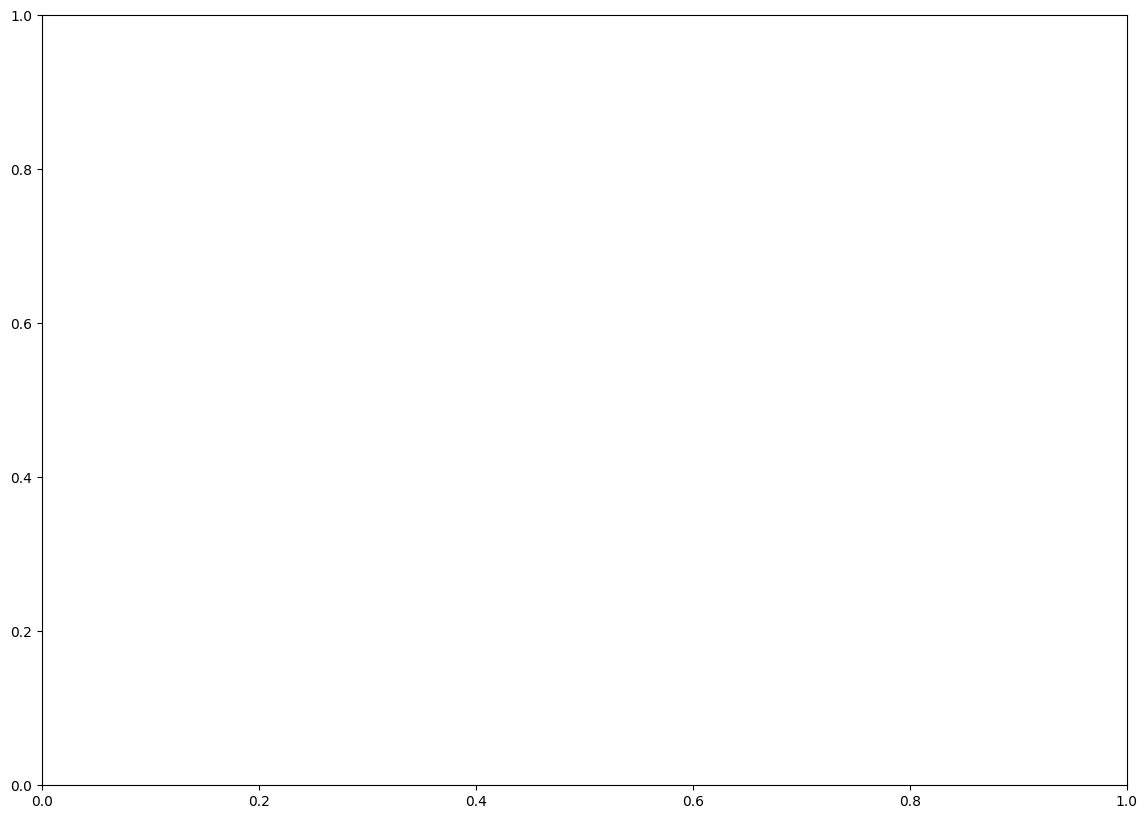

In [34]:
# Mapping system for explainable labels
label_mapping = {
    'seq_v2': 'OpenMP CPU',
    'gpu_v2': 'GPU 2D Grid (CPU integ)',
    'gpu_v3': 'GPU 1D Pairs (CPU integ)',
    'gpu_v4': 'GPU Fully (AoS)',
    'gpu_v5': 'GPU Fully (SoA + 1D pairs)',
    'gpu_v6': 'GPU 1 GPU (NL + block)',
    'gpu_v7': 'GPU 2 GPU (naive)',
}

# 3. GENERATE HISTOGRAM
n_sizes = sorted(data.keys())
ver_keys = ['Cpu_naive', 'seq_v2', 'gpu_v2', 'gpu_v3', 'gpu_v4', 'gpu_v5', 'gpu_v6', 'gpu_v7']

fig, ax = plt.subplots(figsize=(14, 10))
bar_width = 0.1
indices = range(len(n_sizes))

for i, key in enumerate(ver_keys):
    times = [data[n][key][0] for n in n_sizes]
    stds = [data[n][key][1] for n in n_sizes]
    pos = [idx + (i - len(ver_keys)/2) * bar_width + bar_width/2 for idx in indices]
    
    display_label = label_mapping.get(key, key)
    ax.bar(pos, times, bar_width, label=display_label, yerr=stds, capsize=3, alpha=0.8)

# Formatting
ax.set_yscale('log')
ax.set_xticks(indices)
ax.set_xticklabels(n_sizes)
ax.set_xlabel('Problem Size (N)', fontsize=20)
ax.set_ylabel('Execution Time (seconds)', fontsize=20)
ax.tick_params(labelsize=16)

ax.legend(
    loc='upper left',
    bbox_to_anchor=(0.0, -0.25, 1.0, 0.1),   # x, y, width, height in axes coords
    mode='expand',
    ncol=4,
    fontsize=16,
    borderaxespad=0.0
)

plt.tight_layout(rect=[0, 0.05, 1, 1]) 
plt.savefig('performance_variance_plot.png', bbox_inches='tight')
plt.show()